# ML-04 — Search Intelligence Data Contract

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/leiandrei/flyrank-ml-internship-starter/blob/main/work/notebooks/w03_data_contract.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Unit of analysis + time window

*One row = one what, over which dates? State it, then verify it below.*

- **Unit of Analysis - Grain:** One row is represented as a one specific page or content as specified using the `content_id` column which is measured using different metrics.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os, sys, subprocess
import pandas as pd
import seaborn as sns

IN_COLAB = "google.colab" in sys.modules
REPO_URL = "https://github.com/flyrank-bih/flyrank-ml-internship-starter"
REPO_DIR = "flyrank-ml-internship-starter"

if IN_COLAB:
    if not os.path.isdir(REPO_DIR):
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
    os.chdir(REPO_DIR)
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "-r", "requirements.txt"], check=True)
elif os.path.basename(os.getcwd()) == "notebooks":
    os.chdir("..")

df = pd.read_csv("../data/raw/content_refresh_anonymized.csv")
df.head()

,content_id,client_id,search_volume,competition,competition_level,cpc,content_type,main_intent,word_count,char_count,...,char_count_tier,ctr,avg_position,engagement_rate,scroll_rate,ai_traffic_pct,impression_tier,position_tier,trend_direction,trend_pct
0,content_304f48230142,client_f369cb89fc,10.0,0.67,HIGH,2.05,keyword article,transactional,3221.0,20457.0,...,15000-25000,0.76,10.6,5.88,4.55,0.0,good,striking,down,-41.4
1,content_a1fb4e703a9e,client_4e07408562,90.0,0.01,LOW,0.05,keyword article,informational,2481.0,15562.0,...,15000-25000,0.05,20.3,0.00,10.00,0.0,good,page_3_5,down,-57.7
2,content_9aa793d4d895,client_7f2253d7e2,0.0,0.00,LOW,0.00,keyword article,informational,3515.0,23643.0,...,15000-25000,0.09,36.5,0.00,28.57,0.0,good,page_3_5,down,-60.9
3,content_331d6c4de07b,client_19581e27de,10.0,0.00,LOW,0.00,keyword article,commercial,NaN,NaN,...,NaN,0.49,6.2,1.28,3.45,0.0,good,page_1,stable,-13.8
4,content_d99b7a2d90ca,client_3fdba35f04,0.0,0.00,LOW,0.00,keyword article,informational,2803.0,17469.0,...,15000-25000,0.13,44.0,0.00,24.29,0.0,good,page_3_5,down,-34.7


In [2]:
df.columns

Index(['content_id', 'client_id', 'search_volume', 'competition',
       'competition_level', 'cpc', 'content_type', 'main_intent', 'word_count',
       'char_count', 'provider_used', 'model_used', 'impressions_90d',
       'clicks_90d', 'pageviews_90d', 'sessions_90d', 'users_90d',
       'engaged_sessions_90d', 'ai_sessions_90d', 'scroll_events_90d',
       'days_with_impressions', 'days_with_sessions', 'impressions_last_30d',
       'clicks_last_30d', 'sessions_last_30d', 'impressions_prev_30d',
       'clicks_prev_30d', 'sessions_prev_30d', 'content_age_days', 'age_tier',
       'age_tier_order', 'days_since_last_update', 'freshness_tier',
       'word_count_tier', 'char_count_tier', 'ctr', 'avg_position',
       'engagement_rate', 'scroll_rate', 'ai_traffic_pct', 'impression_tier',
       'position_tier', 'trend_direction', 'trend_pct'],
      dtype='str')

## 2. Fields: feature / label / context / excluded

*Sort every field you plan to touch into these four buckets. Excluded needs a why.*
- **Features:** `avg_position`, `search_volumne`, `main_intent`, `content_type`
- **Label:** `ctr`
- **Context:** `content_id` and `client_id`
- **Excluded:** Features columns with such redundancy (for example `scroll_events_90d` and `scroll_rate`), columns that are mathematically ties within another label.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 3. Verify it with queries (grain, counts, missing values, windows)

*Every claim above gets a query cell here. A contract claim without a query next to it is a guess.*

1. `avg_position`: does not mathematically tied to any label, since this fetaure can be determined at the exact moment of where the page can be ranked.
2. `search_volume`: this feature can be certainly be distinguished and be defined in real-time because the volume are increases as new client search for a specific content.
3. `main_intent`: this feature demonstrates the intention of a user that brings them into a specific content.
4. `content_type`: feature that specifies what type of content a specific client is scrolling or searching through.
5. `ctr`: the target label that defines the click rate within a specific content or content type with a specific intent from a client.

<Axes: >

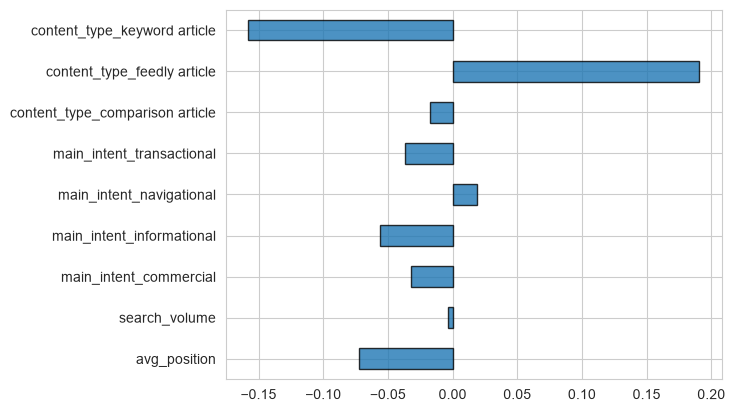

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
subset = df[['avg_position', 'search_volume', 'main_intent', 'content_type', 'ctr']]
subset = pd.get_dummies(subset, columns=['main_intent', 'content_type'], dtype='int')

feature_significance = subset.drop(columns=['ctr']).corrwith(subset['ctr'])

sns.set_style('whitegrid')
feature_significance.plot(kind='barh', alpha=0.8, edgecolor='black')

<Axes: >

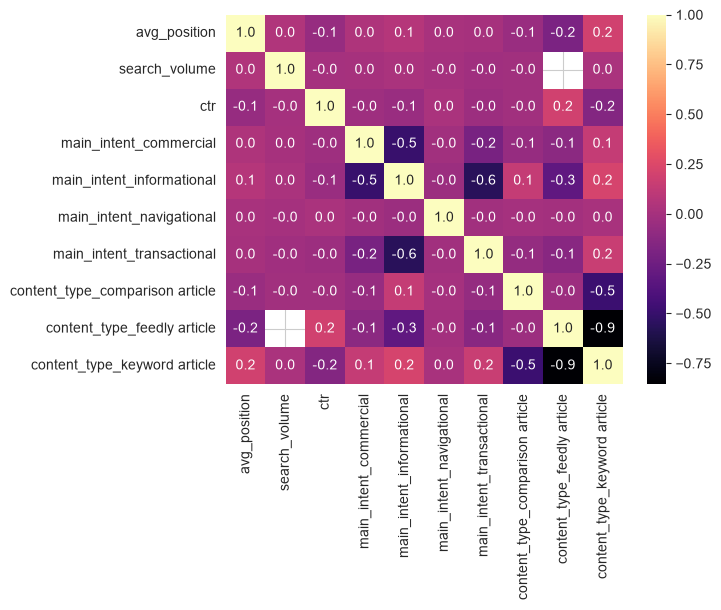

In [5]:
sns.heatmap(subset.corr(numeric_only=True), annot=True, cmap='magma', fmt='.1f')

array([[<Axes: title={'center': 'avg_position'}>,
        <Axes: title={'center': 'search_volume'}>,
        <Axes: title={'center': 'ctr'}>],
       [<Axes: title={'center': 'main_intent_commercial'}>,
        <Axes: title={'center': 'main_intent_informational'}>,
        <Axes: title={'center': 'main_intent_navigational'}>],
       [<Axes: title={'center': 'main_intent_transactional'}>,
        <Axes: title={'center': 'content_type_comparison article'}>,
        <Axes: title={'center': 'content_type_feedly article'}>],
       [<Axes: title={'center': 'content_type_keyword article'}>,
        <Axes: >, <Axes: >]], dtype=object)

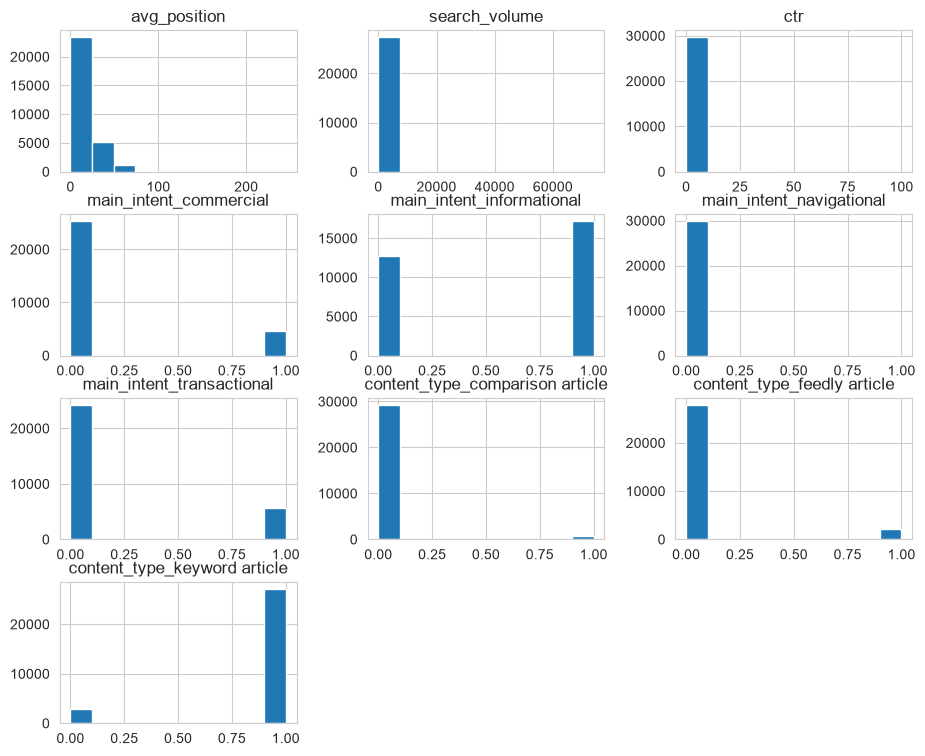

In [6]:
subset.hist(figsize=(11, 9))

In [12]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Feed BOTH the numerator and denominator directly into the features
leak_df = df[['clicks_90d', 'impressions_90d', 'search_volume', 'ctr']].dropna()

x_leak = leak_df.drop('ctr', axis=1)
y_leak = leak_df['ctr']

leaky_rf = RandomForestRegressor(random_state=42).fit(x_leak, y_leak)
r2_leaky = r2_score(y_leak, leaky_rf.predict(x_leak))

print(f"Leaky RF R-squared score: {r2_leaky:.5f}")

Leaky RF R-squared score: 0.99722


In [14]:
clean_df = subset.dropna()

x_clean = clean_df.drop('ctr', axis=1)
y_clean = clean_df.ctr

baseline_model = RandomForestRegressor(random_state=42).fit(x_clean, y_clean)
r2_clean = r2_score(y_clean, baseline_model.predict(x_clean))
print(f"Baseline RF R-squared score: {r2_clean:.5f}")

Baseline RF R-squared score: 0.15327


## 4. Data limits

*What can this data never tell you? Unbalanced history, GSC-only early rows, window overlaps.*

- **What can this data never tell you:** This dataset consists of aggregated, GSC-only metrics and window overlaps, which by design obscure the daily volatility of the SERP, as well as specific user context and visual disruptions of dynamic search features. Moreover, it does not have the qualitative text of the actual meta titles and descriptions, and can model macro-level discovery trends, but never reveal the complex human reasoning behind a specific click.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.